# Heston Path Simulation Playground

This notebook visualises simulated stock price and variance paths under the Heston model. It is useful for building intuition about volatility clustering and leverage before plugging the simulator into Monte Carlo pricing.


In [11]:
# Auto-reload modules when they change (useful during development)
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

PROJECT_ROOT = Path("..")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.heston_model import HestonModel

# Research paper quality plotting settings
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'axes.linewidth': 1.0,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.5,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.axisbelow': True,
})

# Color palette for research papers (professional, colorblind-friendly)
COLORS = {
    'primary': '#2E86AB',      # Blue
    'secondary': '#A23B72',   # Purple
    'accent': '#F18F01',      # Orange
    'success': '#C73E1D',     # Red
    'neutral': '#6C757D',     # Gray
    'dark': '#212529',        # Dark gray
}

## Simulator configuration (no calibrated)


In [13]:
# Initialize Heston model
model = HestonModel(
    kappa=1.5,
    theta=0.04,
    sigma=0.3,
    rho=-0.7,
    v0=0.04,
    r=0.02,
    q=0.00,
)

# Simulation parameters
S0 = 100
T = 2.0
n_steps = 252 * 2  # 2 years of daily steps
n_paths = 10000

In [14]:
# Simulate paths using the HestonModel
times, spot_paths, var_paths = model.simulate_paths(S0, T, n_steps, n_paths, seed=42)
print(f"Simulated {n_paths} paths with {n_steps} steps each")
print(f"Spot paths shape: {spot_paths.shape}")
print(f"Variance paths shape: {var_paths.shape}")
spot_paths.shape, var_paths.shape

Simulated 10000 paths with 504 steps each
Spot paths shape: (10000, 505)
Variance paths shape: (10000, 505)


((10000, 505), (10000, 505))

## Sample paths

Visualise a handful of price/variance sample paths to get intuition about stochastic volatility and the leverage effect.


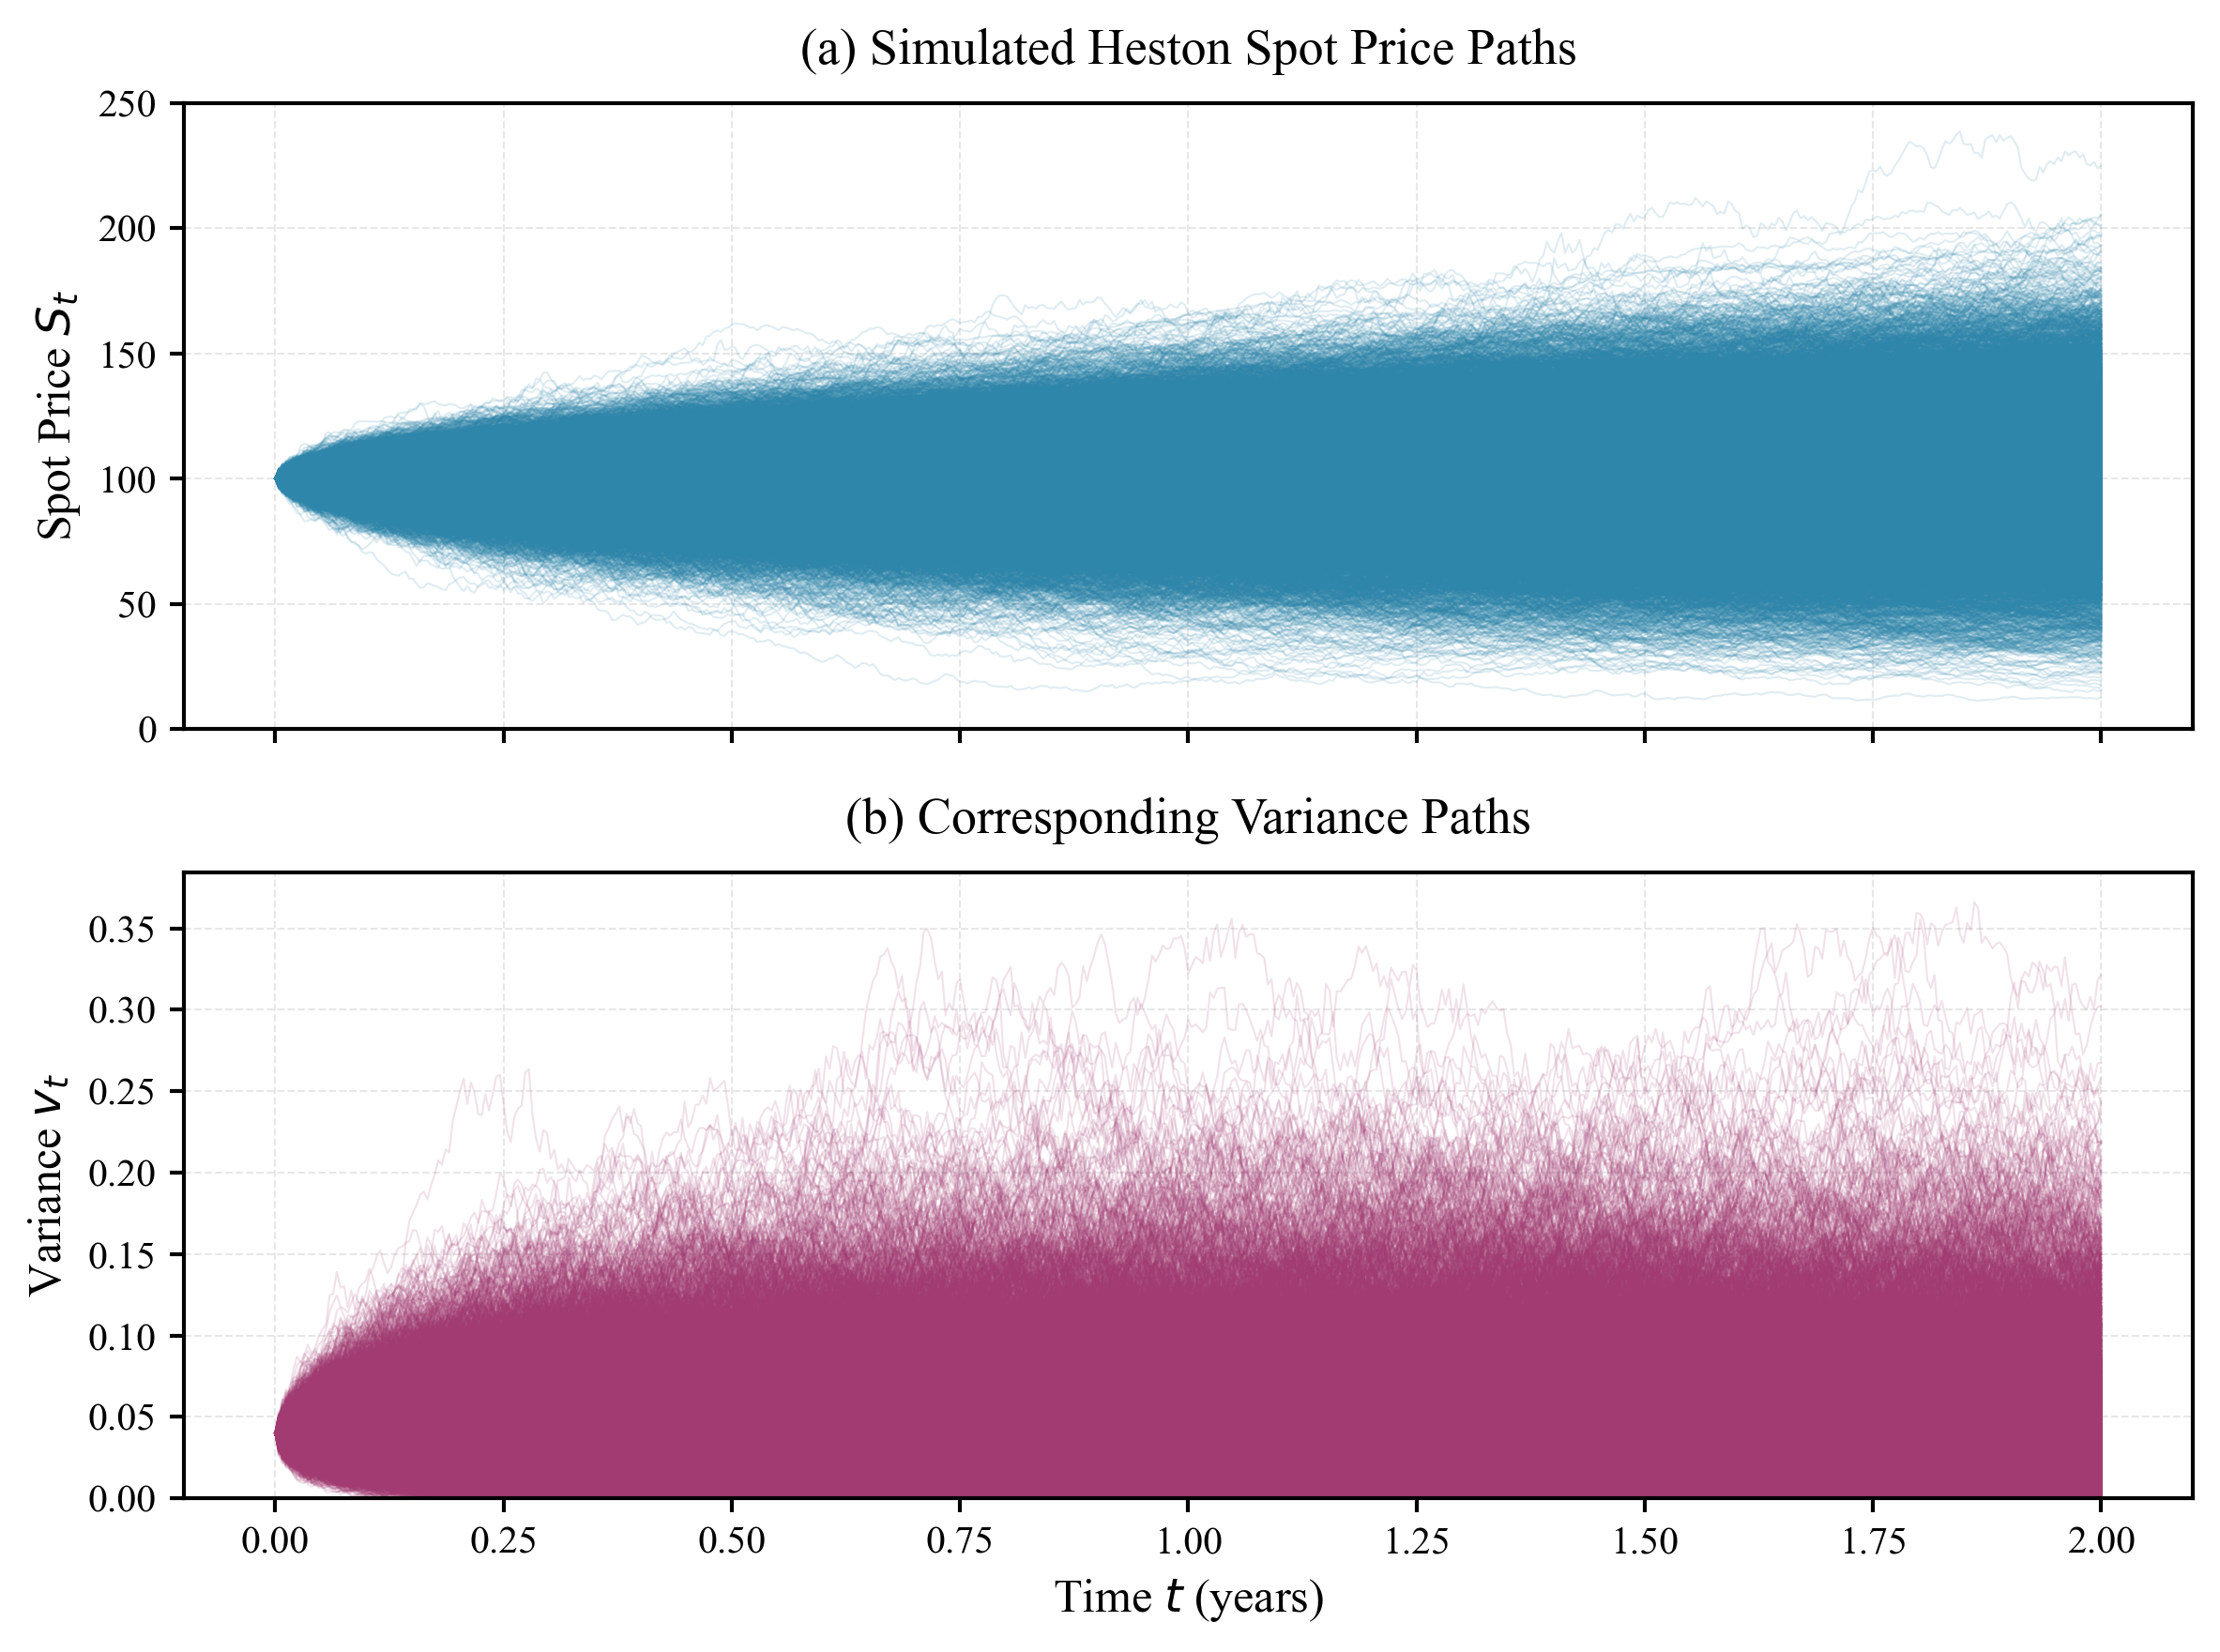

In [20]:
n_show = 10000
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Plot spot paths
for i in range(n_show):
    ax[0].plot(times, spot_paths[i], color=COLORS['primary'], alpha=0.15, linewidth=0.5)
ax[0].set_ylabel(r'Spot Price $S_t$', fontsize=12)
ax[0].set_title('(a) Simulated Heston Spot Price Paths', fontsize=13, pad=10)
ax[0].grid(True, alpha=0.3, linestyle='--')
ax[0].set_ylim(bottom=0)

# Plot variance paths
for i in range(n_show):
    ax[1].plot(times, var_paths[i], color=COLORS['secondary'], alpha=0.15, linewidth=0.5)
ax[1].set_ylabel(r'Variance $v_t$', fontsize=12)
ax[1].set_xlabel('Time $t$ (years)', fontsize=12)
ax[1].set_title('(b) Corresponding Variance Paths', fontsize=13, pad=10)
ax[1].grid(True, alpha=0.3, linestyle='--')
ax[1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

## Distribution snapshot

Check that the simulated terminal prices exhibit skew/leptokurtic behaviour compared with a lognormal baseline.


<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\s'
/var/folders/w1/k7fwgp6d65v95lj5q8pp5tx80000gn/T/ipykernel_65380/365105542.py:17: SyntaxWarning: invalid escape sequence '\m'
  label=f'Gaussian Fit ($\mu={mu:.3f}$, $\sigma={sigma:.3f}$)')
/var/folders/w1/k7fwgp6d65v95lj5q8pp5tx80000gn/T/ipykernel_65380/365105542.py:17: SyntaxWarning: invalid escape sequence '\s'
  label=f'Gaussian Fit ($\mu={mu:.3f}$, $\sigma={sigma:.3f}$)')


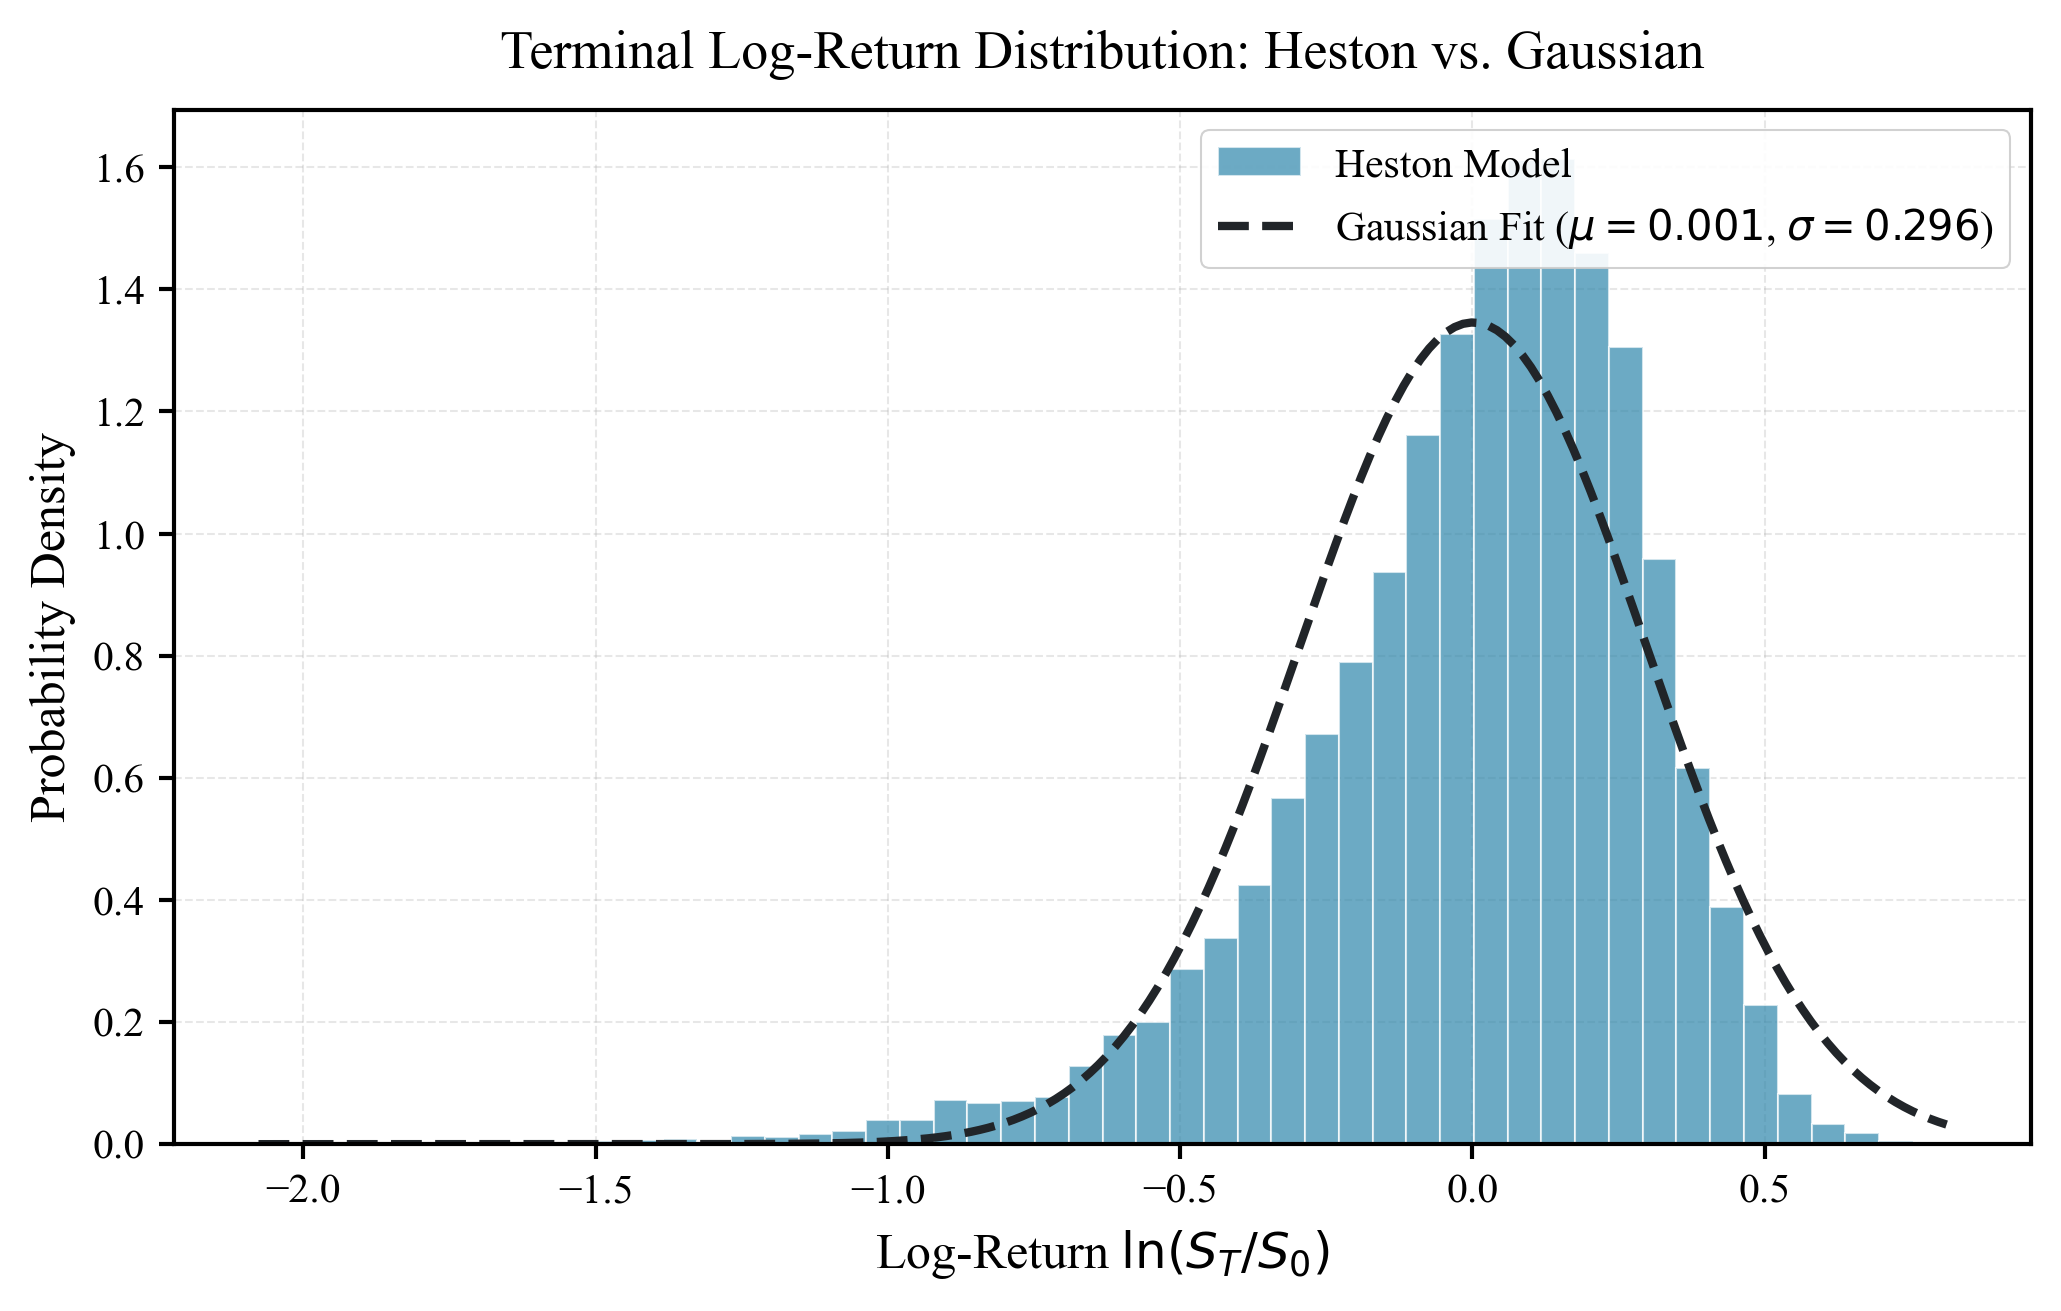

In [17]:
terminal = spot_paths[:, -1]
log_returns = np.log(terminal / S0)

fig, ax = plt.subplots(figsize=(7, 4.5))

# Histogram of Heston log-returns
n, bins, patches = ax.hist(log_returns, bins=50, density=True, alpha=0.7, 
                           color=COLORS['primary'], edgecolor='white', linewidth=0.5,
                           label='Heston Model')

# Overlay Gaussian fit
mu = np.mean(log_returns)
sigma = np.std(log_returns)
x = np.linspace(log_returns.min(), log_returns.max(), 200)
normal_pdf = 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
ax.plot(x, normal_pdf, color=COLORS['dark'], linewidth=2, linestyle='--', 
        label=f'Gaussian Fit ($\mu={mu:.3f}$, $\sigma={sigma:.3f}$)')

ax.set_xlabel(r'Log-Return $\ln(S_T/S_0)$', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('Terminal Log-Return Distribution: Heston vs. Gaussian', fontsize=13, pad=10)
ax.legend(loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


## Monte Carlo pricing sanity check

We can approximate a call price via Monte Carlo and compare it with the analytical Heston FFT value to ensure the simulator is unbiased (within Monte Carlo error).


In [18]:
K = 100
payoffs = np.maximum(spot_paths[:, -1] - K, 0)
mc_price = np.exp(-sim.r * T) * payoffs.mean()
mc_std = np.exp(-sim.r * T) * payoffs.std(ddof=1) / np.sqrt(n_paths)

from src.heston_model import HestonModel

analytic = HestonModel(
    kappa=sim.kappa,
    theta=sim.theta,
    sigma=sim.sigma,
    rho=sim.rho,
    v0=sim.v0,
    r=sim.r,
    q=sim.q,
)
fft_price = analytic.call_price_fft(S0, K, T, N=8192, eta=0.05, alpha=1.3)

print(f"Monte Carlo price: {mc_price:.4f} ± {1.96 * mc_std:.4f}")
print(f"FFT price:        {fft_price:.4f}")

Monte Carlo price: 12.6894 ± 0.3234
FFT price:        12.6924
